In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2025-06-21 11:26:37.411973: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750501597.692081    5976 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750501597.782713    5976 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750501598.260001    5976 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750501598.260111    5976 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750501598.260120    5976 computation_placer.cc:177] computation placer alr

### 1. Load and Preprocess the MNIST Dataset

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step


In [3]:
# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [4]:
# Flatten images from 28x28 to 784 for feed-forward network
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [5]:
# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [6]:
x_train.shape, x_test.shape

((60000, 784), (10000, 784))

### 3. Design the Neural Network Architecture

In [7]:
# Build the model
model = models.Sequential([
    layers.Input(shape=(784,)),  # Input layer
    layers.Dense(128, activation='relu'),  # Hidden layer 1
    layers.Dense(64, activation='relu'),   # Hidden layer 2
    layers.Dense(10, activation='softmax') # Output layer
])

2025-06-21 11:31:08.406650: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the Model

In [10]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10


2025-06-21 11:35:13.625494: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150528000 exceeds 10% of free system memory.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8657 - loss: 0.4669 - val_accuracy: 0.9605 - val_loss: 0.1359
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9644 - loss: 0.1202 - val_accuracy: 0.9598 - val_loss: 0.1286
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9748 - loss: 0.0783 - val_accuracy: 0.9695 - val_loss: 0.1010
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9834 - loss: 0.0547 - val_accuracy: 0.9736 - val_loss: 0.0909
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9874 - loss: 0.0418 - val_accuracy: 0.9732 - val_loss: 0.0939
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9894 - loss: 0.0322 - val_accuracy: 0.9701 - val_loss: 0.1056
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9904 - loss: 0.0271 - val_accuracy: 0.9775 - val_loss: 0.0858
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9928 - loss: 0.0216 - val_accurac

### 5. Evaluate the Model

In [11]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")

Test accuracy: 0.9735, Test loss: 0.1114


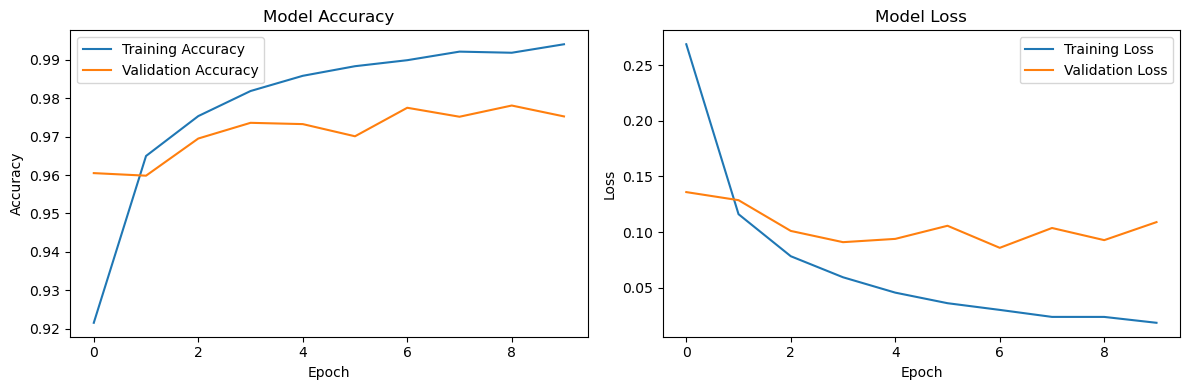

In [12]:
# Plot accuracy and loss curves
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### 6. Hyperparameter Tuning

In [13]:
# Function to build and train model with given learning rate
def train_model(learning_rate, batch_size=32):
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        x_train, y_train,
        epochs=10,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )
    return history, model.evaluate(x_test, y_test, verbose=0)[1]

In [14]:
# Test different learning rates
learning_rates = [0.0001, 0.001, 0.01]
batch_size = 32
results = {}

for lr in learning_rates:
    print(f"Training with learning rate: {lr}")
    history, test_acc = train_model(lr, batch_size)
    results[lr] = {'history': history, 'test_accuracy': test_acc}
    print(f"Test accuracy: {test_acc:.4f}")

Training with learning rate: 0.0001


2025-06-21 11:38:37.460440: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150528000 exceeds 10% of free system memory.


Test accuracy: 0.9669
Training with learning rate: 0.001


2025-06-21 11:39:19.637903: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150528000 exceeds 10% of free system memory.


Test accuracy: 0.9766
Training with learning rate: 0.01


2025-06-21 11:39:57.630543: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150528000 exceeds 10% of free system memory.


Test accuracy: 0.9604


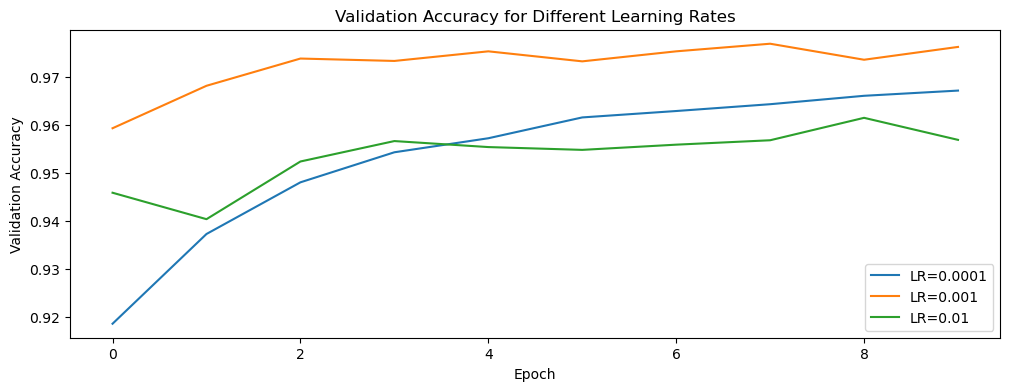

In [15]:
# Plot results
plt.figure(figsize=(12, 4))
for lr in learning_rates:
    plt.plot(results[lr]['history'].history['val_accuracy'], label=f'LR={lr}')
plt.title('Validation Accuracy for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

### Save and Use the Model



In [16]:
# Save the model
model.save('mnist_model.keras')

In [17]:
loaded_model = tf.keras.models.load_model('mnist_model.keras')

In [18]:
# Predict on a single test image
sample_image = x_test[0].reshape(1, 784)
prediction = loaded_model.predict(sample_image)
predicted_digit = np.argmax(prediction)
print(f"Predicted digit: {predicted_digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted digit: 7


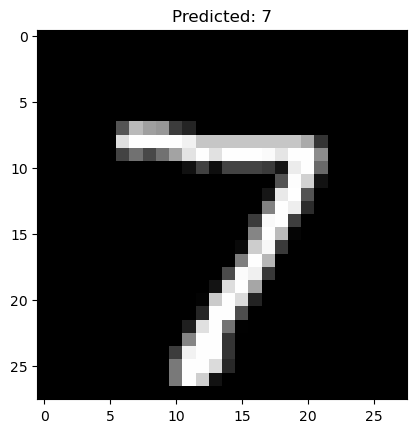

In [20]:
# Visualize the image
plt.imshow(x_test[0].reshape(28, 28), cmap='gray')  # Reshape to 28x28
plt.title(f"Predicted: {predicted_digit}")
plt.show()